In [1]:
import slangpy as spy
import numpy as np
import quaternion
import pathlib
import matplotlib.pyplot as plt
from pyglm import glm
from PIL import Image
import jax
import jax.numpy as jnp

from bvhgs.camera import Camera
from bvhgs.renderer import Renderer
from bvhgs.gaussian import GaussianCloud

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


# Load a COLMAP DB

In [2]:
import pycolmap

In [3]:
maps = pycolmap.Reconstruction("../resources/dataset/tandt_db/tandt/truck/sparse/0/")
maps

Reconstruction(num_cameras=1, num_images=251, num_reg_images=251, num_points3D=136029)

In [4]:
colmap_image = maps.images[1]
print(colmap_image.summary())

Image:
    image_id = 1
    camera_id = 1
    camera: Camera:
        camera_id = 1
        model = CameraModelId.PINHOLE
        width = 1957
        height = 1091
        focal_length = 1163.2547280302354
        focal_length_x = 1163.2547280302354
        focal_length_y = 1156.280404988286
        has_prior_focal_length = False
        principal_point_x = 978.5
        principal_point_y = 545.5
        params_info = fx, fy, cx, cy
        params = [1163.25472803 1156.28040499  978.5         545.5       ]
    name = 000001.jpg
    cam_from_world: Rigid3d:
        rotation: Rotation3d:
            quat = [-0.03458228  0.32694849  0.00326725  0.94440356]
        translation = [-1.233242   -0.47090759  3.94507725]
    has_pose = True
    points2D = L ... 8638 elements ... ]
    num_points3D = 4118


In [5]:
colmap_cam = colmap_image.camera
pose = colmap_image.cam_from_world.inverse()
rotation = glm.quat(pose.rotation.quat)
position = glm.vec3(pose.translation)
rotation, position

(quat( 0.0345823, -0.326948, -0.00326725, 0.944404 ),
 vec3( 3.39896, 0.683534, -2.29915 ))

In [6]:
if len(colmap_cam.params) == 4:
    fx, fy, _, _ = colmap_cam.params
    f = (fx + fy) / 2
    f = f.item()
else:
    f, _, _ = colmap_cam.params
    f = f.item()
sx = colmap_cam.width
sy = colmap_cam.height
f, sx, sy

(1159.7675665092606, 1957, 1091)

In [7]:
camera = Camera(
    rotation=rotation,
    position=position,
    sensor_size=glm.uvec2(sx, sy),
    focal_length=f
)
camera.to_slang()

{'_rotation': [0.32694852352142334,
  0.0032672483939677477,
  -0.9444036483764648,
  0.03458227962255478],
 '_translation': vec3( 1.19875, 0.830461, 3.8961 ),
 '_sensorSize': uvec2( 1957, 1091 ),
 '_focalLength': 1159.7675665092606,
 '_nearPlane': 0.1,
 '_farPlane': 1000.0}

In [8]:
# Load the image.
image_dir = pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
image_path = image_dir / colmap_image.name
image = Image.open(image_path)
image = image.resize((sx, sy))

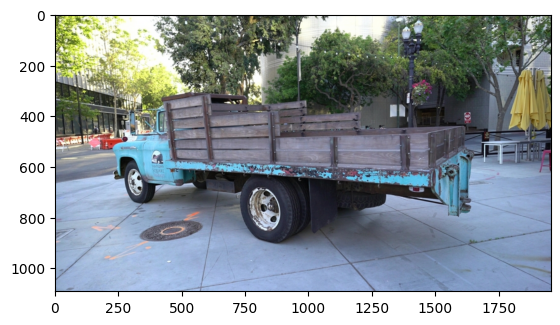

In [9]:
image_arr = np.array(image)
image_arr = image_arr.astype(np.float32) / 255
plt.imshow(image_arr)

# Load COLMAP Point Cloud

In [10]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"))
len(gaussians)

104692

# Renderer

In [11]:
render = Renderer(gaussians, camera)

In [12]:
render.render()

[WARN] (rhi) slang: metal 32023.619: /Users/fangjun/Documents/stanford/bvhgs/src/bvhgs/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



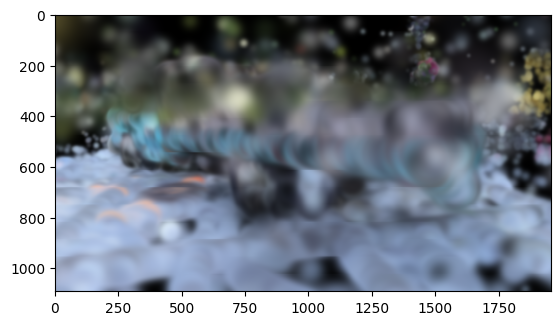

In [13]:
render_arr = render.render_target.to_numpy()[:, :, :3]
render_arr = np.flip(render_arr, axis=(0, 1))
plt.imshow(render_arr)

# Image Lnoss

In [14]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [15]:
image_loss(render_arr, image_arr)

Array(0.08581953, dtype=float32)

In [16]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

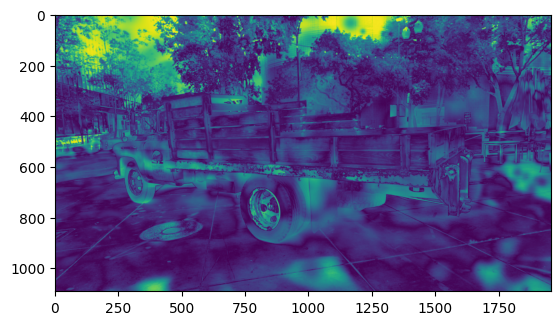

In [17]:
loss, render_target_grad = loss_grad(render_arr, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

## A Very Simple Gradient Descent

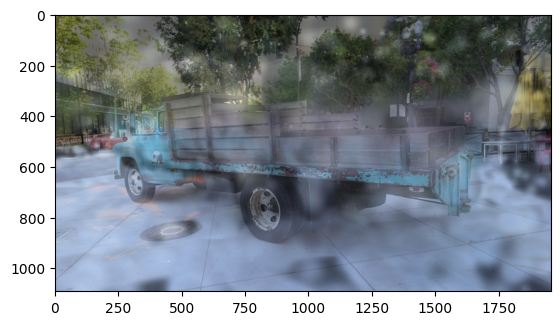

In [18]:
lr = 5e4
num_epochs = 32

for i in range(num_epochs):
    loss, render_target_grad = loss_grad(render_arr, image_arr)
    render_arr -= render_target_grad * lr

plt.imshow(render_arr)